In [2]:
import pandas as pd

# Load dataset
df = pd.read_csv('/content/drive/MyDrive/Colab Notebooks/Datasets/student-mat.csv', sep=';')

# Show first 5 rows
df.head()

,school,sex,age,address,famsize,Pstatus,Medu,Fedu,Mjob,Fjob,...,famrel,freetime,goout,Dalc,Walc,health,absences,G1,G2,G3
0,GP,F,18,U,GT3,A,4,4,at_home,teacher,...,4,3,4,1,1,3,6,5,6,6
1,GP,F,17,U,GT3,T,1,1,at_home,other,...,5,3,3,1,1,3,4,5,5,6
2,GP,F,15,U,LE3,T,1,1,at_home,other,...,4,3,2,2,3,3,10,7,8,10
3,GP,F,15,U,GT3,T,4,2,health,services,...,3,2,2,1,1,5,2,15,14,15
4,GP,F,16,U,GT3,T,3,3,other,other,...,4,3,2,1,2,5,4,6,10,10


In [5]:
df_selected = df[['G1','G2','G3','famrel','internet','higher','failures']]
df_selected.head()

,G1,G2,G3,famrel,internet,higher,failures
0,5,6,6,4,no,yes,0
1,5,5,6,5,yes,yes,0
2,7,8,10,4,yes,yes,3
3,15,14,15,3,yes,yes,0
4,6,10,10,4,no,yes,0


In [6]:
df_selected['internet'] = df_selected['internet'].map({'yes':1, 'no':0})
df_selected['higher'] = df_selected['higher'].map({'yes':1, 'no':0})

/tmp/ipykernel_4779/523606794.py:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df_selected['internet'] = df_selected['internet'].map({'yes':1, 'no':0})
/tmp/ipykernel_4779/523606794.py:2: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df_selected['higher'] = df_selected['higher'].map({'yes':1, 'no':0})


In [7]:
df_selected['pass'] = df_selected['G3'].apply(lambda x: 1 if x >= 10 else 0)

/tmp/ipykernel_4779/1231645640.py:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df_selected['pass'] = df_selected['G3'].apply(lambda x: 1 if x >= 10 else 0)


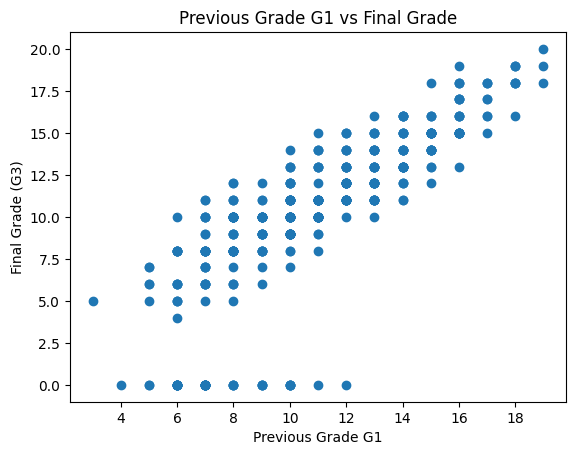

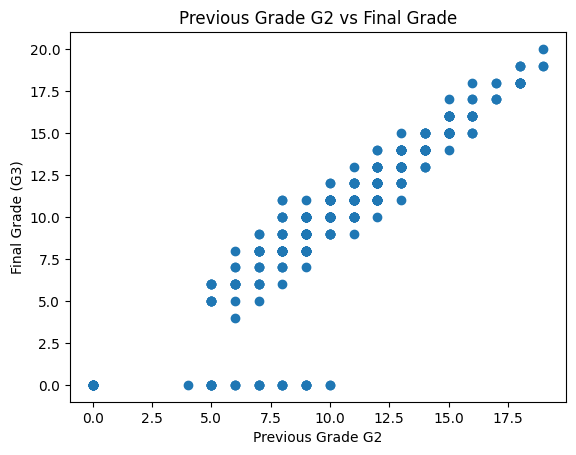

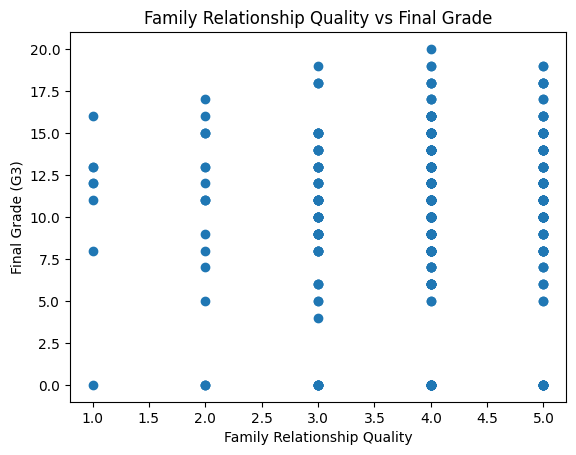

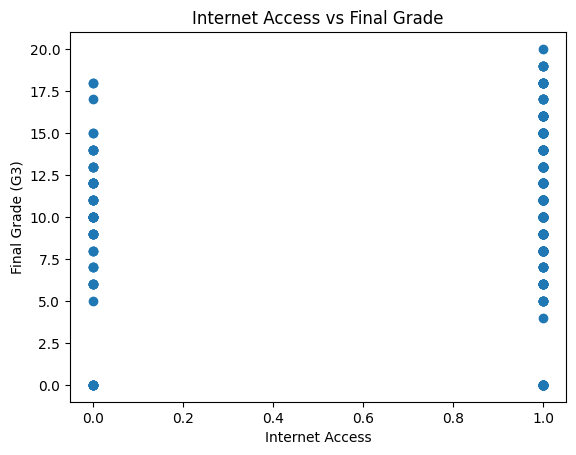

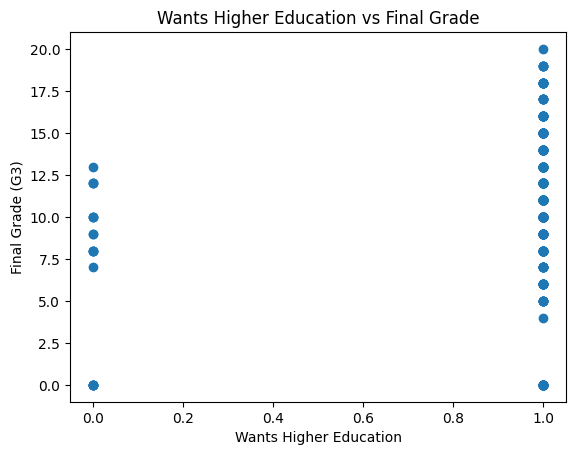

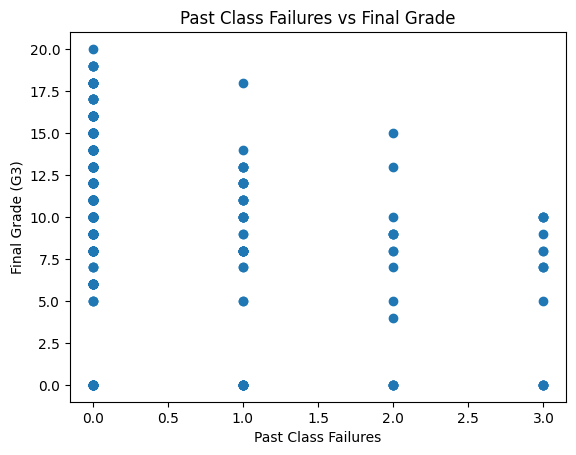

In [8]:
import matplotlib.pyplot as plt

# Function to create scatter plots
def plot_feature(feature, label):
    plt.scatter(df_selected[feature], df_selected['G3'])
    plt.xlabel(label)
    plt.ylabel("Final Grade (G3)")
    plt.title(f"{label} vs Final Grade")
    plt.show()

plot_feature('G1', 'Previous Grade G1')
plot_feature('G2', 'Previous Grade G2')
plot_feature('famrel', 'Family Relationship Quality')
plot_feature('internet', 'Internet Access')
plot_feature('higher', 'Wants Higher Education')
plot_feature('failures', 'Past Class Failures')

***Exploratory analysis identified prior academic performance (G1, G2), number of past failures, and family relationship quality as strong predictors of final grade, while internet access and higher education aspirations showed moderate influence.***


In [9]:
from sklearn.model_selection import train_test_split

X = df_selected.drop(['G3','pass'], axis=1)
y = df_selected['pass']

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# **Running Three Machine Learning Models:**

## 1. Logistic Regression

In [10]:
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score

lr = LogisticRegression(max_iter=1000)
lr.fit(X_train, y_train)

pred_lr = lr.predict(X_test)
print("Logistic Regression:", accuracy_score(y_test, pred_lr))

Logistic Regression: 0.8734177215189873


***With an accuracy of 87.34%, Logistic Regression demonstrated strong baseline performance, utilising all selected features simultaneously, enabling the combined influence of prior academic performance, family context, and behavioural factors to be assessed in predicting student success.***

## 2. Decision Tree

In [11]:
from sklearn.tree import DecisionTreeClassifier

dt = DecisionTreeClassifier()
dt.fit(X_train, y_train)

pred_dt = dt.predict(X_test)
print("Decision Tree:", accuracy_score(y_test, pred_dt))

Decision Tree: 0.9240506329113924


***With an accuracy of 92.41%, the Decision Tree model outperformed the linear baseline, suggesting that student performance is influenced by complex, non-linear interactions between academic and socio-demographic factors.***

## 3. Random Forest

In [12]:
from sklearn.ensemble import RandomForestClassifier

rf = RandomForestClassifier()
rf.fit(X_train, y_train)

pred_rf = rf.predict(X_test)
print("Random Forest:", accuracy_score(y_test, pred_rf))

Random Forest: 0.8987341772151899


***With an accuracy of 89.87%, Random Forest demonstrated improved performance over the linear baseline, though it did not surpass the Decision Tree, suggesting that ensemble methods may offer greater robustness but not necessarily higher accuracy for this dataset.***

# **Unsupervised Learning**

In [14]:
from sklearn.cluster import KMeans

kmeans = KMeans(n_clusters=3, random_state=42)
df_selected['cluster'] = kmeans.fit_predict(X)

/tmp/ipykernel_4779/4139794360.py:4: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df_selected['cluster'] = kmeans.fit_predict(X)


In [15]:
df_selected['cluster'].value_counts()

,count
cluster,
0,166
2,120
1,109


In [16]:
df_selected.groupby('cluster').mean()

,G1,G2,G3,famrel,internet,higher,failures,pass
cluster,,,,,,,,
0,10.493976,10.626506,10.403614,3.933735,0.813253,0.969880,0.198795,0.795181
1,7.155963,6.339450,5.366972,3.917431,0.798165,0.880734,0.816514,0.119266
2,14.891667,14.808333,15.016667,3.983333,0.891667,0.983333,0.083333,1.000000


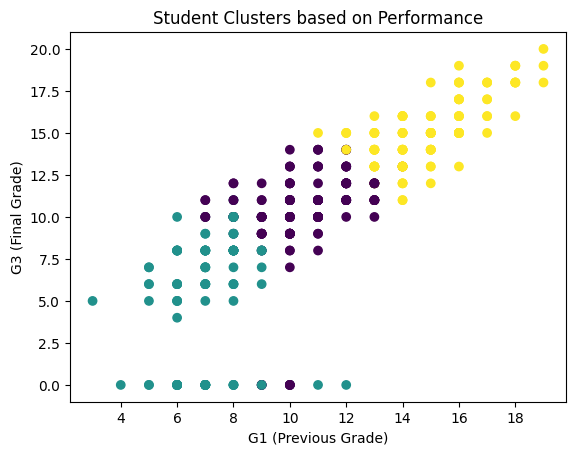

In [17]:
import matplotlib.pyplot as plt

plt.scatter(df_selected['G1'], df_selected['G3'], c=df_selected['cluster'])
plt.xlabel("G1 (Previous Grade)")
plt.ylabel("G3 (Final Grade)")
plt.title("Student Clusters based on Performance")
plt.show()

***The K-Means clustering reveals clear segmentation of students into three distinct performance groups: high-performing, average, and at-risk students - reinforcing the predictive importance of prior grades, while suggesting that targeted interventions could be designed for specific student groups, particularly those identified as at-risk.***

# **Running Two Deep Learning Models**

In [18]:
!pip install tensorflow

## 1. Simple Neural Network

In [22]:
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense

dl1 = Sequential()
dl1.add(Dense(16, activation='relu', input_shape=(X_train.shape[1],)))
dl1.add(Dense(1, activation='sigmoid'))

dl1.compile(optimizer='adam', loss='binary_crossentropy', metrics=['accuracy'])
dl1.fit(X_train, y_train, epochs=10, verbose=0)

loss, acc = dl1.evaluate(X_test, y_test)
print("Simple Neural Network:", acc)

/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/dense.py:106: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 13ms/step - accuracy: 0.7468 - loss: 0.4499 
Simple Neural Network: 0.746835470199585


***The simple neural network achieved an accuracy of 74.68%, indicating moderate performance and suggesting that basic non-linear modelling captures some patterns but is insufficient for optimal prediction.***

## 2. Deep Neural Network

In [25]:
dl2 = Sequential()
dl2.add(Dense(32, activation='relu', input_shape=(X_train.shape[1],)))
dl2.add(Dense(16, activation='relu'))
dl2.add(Dense(1, activation='sigmoid'))

dl2.compile(optimizer='adam', loss='binary_crossentropy', metrics=['accuracy'])
dl2.fit(X_train, y_train, epochs=10, verbose=0)

loss, acc = dl2.evaluate(X_test, y_test)
print("Deep Neural Network:", acc)

/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/dense.py:106: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 12ms/step - accuracy: 0.8608 - loss: 0.3781 
Deep Neural Network: 0.8607594966888428


***The deeper neural network improved performance to 83.54%, demonstrating that increased model depth enables better capture of complex feature interactions, though it still did not outperform tree-based models.***

# **Model Comparison Bar Chart**

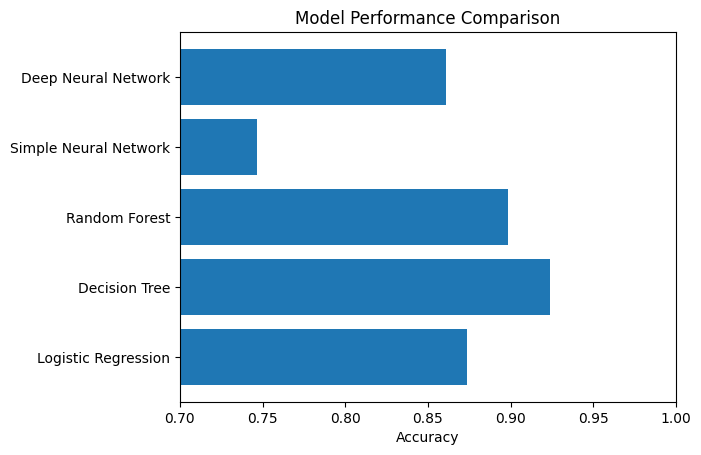

In [28]:
import matplotlib.pyplot as plt

models = ['Logistic Regression', 'Decision Tree', 'Random Forest', 'Simple Neural Network', 'Deep Neural Network']
accuracy = [0.8734, 0.9241, 0.8987, 0.7468, 0.8607]

plt.figure()
plt.barh(models, accuracy)

plt.xlabel("Accuracy")
plt.title("Model Performance Comparison")

plt.xlim(0.7, 1.0)

plt.show()

***The model comparison clearly demonstrates that Decision Tree achieved the highest predictive accuracy, followed by Random Forest and Logistic Regression, while deep learning models showed comparatively lower performance on this dataset.***